In [459]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [460]:
customers = pd.read_csv('customers_sample.csv')
category_spends = pd.read_csv('category_spends_sample.csv')
baskets = pd.read_csv('baskets_sample.csv')
lineitems = pd.read_csv('lineitems_sample.csv')

print("customers:", customers.shape)
print("category_spends:", category_spends.shape)
print("baskets:", baskets.shape)
print("lineitems:", lineitems.shape)

customers: (3000, 6)
category_spends: (3000, 21)
baskets: (195547, 5)
lineitems: (1461315, 6)


In [461]:
display(customers.head())
display(category_spends.head())
display(baskets.head())
display(lineitems.head())

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,£631.12,£2.87
1,4757,248,333,1.342742,£452.42,£1.82
2,144,226,303,1.340708,£261.16,£1.16
3,572,285,346,1.214035,£638.79,£2.24
4,669,285,324,1.136842,£561.42,£1.97


,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,frozen,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,£64.58,£35.91,£107.78,£27.08,£29.59,£0.00,£54.83,£6.35,£22.83,£21.51,£28.62,£162.10,£28.02,£28.12,£28.54,£2.00,£15.00,£7.48,£0.00,£0.84
1,8171,£16.89,£37.24,£28.84,£33.43,£66.40,£0.00,£22.06,£12.09,£2.34,£78.74,£26.44,£0.00,£8.42,£2.65,£3.76,£0.00,£0.00,£9.99,£0.00,£0.00
2,1060,£87.30,£82.98,£49.88,£20.57,£37.04,£0.00,£9.85,£57.98,£31.12,£14.53,£54.65,£0.00,£0.00,£2.60,£0.00,£18.00,£20.00,£106.46,£0.00,£0.00
3,3728,£84.05,£186.56,£175.50,£119.84,£111.08,£0.00,£13.05,£25.54,£124.42,£15.24,£0.95,£127.70,£0.00,£0.00,£0.00,£4.00,£0.00,£0.00,£0.00,£4.50
4,14621,£35.16,£121.31,£79.23,£29.03,£37.17,£0.00,£40.06,£0.00,£4.68,£3.33,£36.24,£0.00,£2.55,£99.16,£0.00,£0.00,£0.00,£3.40,£0.00,£0.00


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,£3.09,3
1,4047,2007-03-01 07:13:00,9,£7.99,5
2,3571,2007-03-01 07:27:00,9,£37.06,6
3,4079,2007-03-01 07:34:00,11,£11.91,5
4,6063,2007-03-01 07:36:00,3,£1.45,1


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,£1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,£4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,£0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,£0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,£1.59


In [462]:
def parse_pounds(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace("£", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

# Apply to customers
customers["total_spend"] = parse_pounds(customers["total_spend"])
customers["average_spend"] = parse_pounds(customers["average_spend"])

# Apply to baskets
baskets["basket_spend"] = parse_pounds(baskets["basket_spend"])

# Apply to category_spends
cat_cols = [c for c in category_spends.columns if c != "customer_number"]
for c in cat_cols:
    category_spends[c] = parse_pounds(category_spends[c])

# Apply to lineitems
lineitems["spend"] = parse_pounds(lineitems["spend"])

In [463]:
display(customers.head())
display(category_spends.head())
display(baskets.head())
display(lineitems.head())

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,631.12,2.87
1,4757,248,333,1.342742,452.42,1.82
2,144,226,303,1.340708,261.16,1.16
3,572,285,346,1.214035,638.79,2.24
4,669,285,324,1.136842,561.42,1.97


,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,frozen,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,64.58,35.91,107.78,27.08,29.59,0.0,54.83,6.35,22.83,21.51,28.62,162.1,28.02,28.12,28.54,2.0,15.0,7.48,0.0,0.84
1,8171,16.89,37.24,28.84,33.43,66.40,0.0,22.06,12.09,2.34,78.74,26.44,0.0,8.42,2.65,3.76,0.0,0.0,9.99,0.0,0.00
2,1060,87.30,82.98,49.88,20.57,37.04,0.0,9.85,57.98,31.12,14.53,54.65,0.0,0.00,2.60,0.00,18.0,20.0,106.46,0.0,0.00
3,3728,84.05,186.56,175.50,119.84,111.08,0.0,13.05,25.54,124.42,15.24,0.95,127.7,0.00,0.00,0.00,4.0,0.0,0.00,0.0,4.50
4,14621,35.16,121.31,79.23,29.03,37.17,0.0,40.06,0.00,4.68,3.33,36.24,0.0,2.55,99.16,0.00,0.0,0.0,3.40,0.0,0.00


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,3.09,3
1,4047,2007-03-01 07:13:00,9,7.99,5
2,3571,2007-03-01 07:27:00,9,37.06,6
3,4079,2007-03-01 07:34:00,11,11.91,5
4,6063,2007-03-01 07:36:00,3,1.45,1


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,1.59


In [464]:
baskets["purchase_time"] = pd.to_datetime(baskets["purchase_time"], errors="coerce")        # Convert purchase_time to datetime, coercing errors to NaT
lineitems["purchase_time"] = pd.to_datetime(lineitems["purchase_time"], errors="coerce")    

baskets["purchase_time"].min(), baskets["purchase_time"].max()

(Timestamp('2007-03-01 07:06:00'), Timestamp('2007-08-31 21:55:00'))

In [465]:
# Bakery spend per customer from lineitems
bakery_from_lineitems = (
    lineitems.loc[lineitems["category"].str.upper().eq("BAKERY")]                                       # Filter lineitems for category "BAKERY" (case-insensitive)
    .groupby("customer_number")["spend"]
    .sum()
    .rename("bakery_recalc")
    .reset_index()
)
category_spends = category_spends.merge(bakery_from_lineitems, on="customer_number", how="left")        # Merge with category_spends to get bakery_recalc column
category_spends["bakery_recalc"] = category_spends["bakery_recalc"].fillna(0.0)                         # Fill NaN values with 0.0

if "bakery" in category_spends.columns:                                                                 # If original bakery column exists, compare with recalculated values
    category_spends["bakery"] = category_spends["bakery_recalc"]    

category_spends.drop(columns=["bakery_recalc"], inplace=True)

In [466]:
category_spends["bakery"].describe()

count    3000.000000
mean       38.210123
std        36.496115
min         0.000000
25%        14.635000
50%        29.270000
75%        50.050000
max       444.370000
Name: bakery, dtype: float64

## EDA — quick distribution snapshots

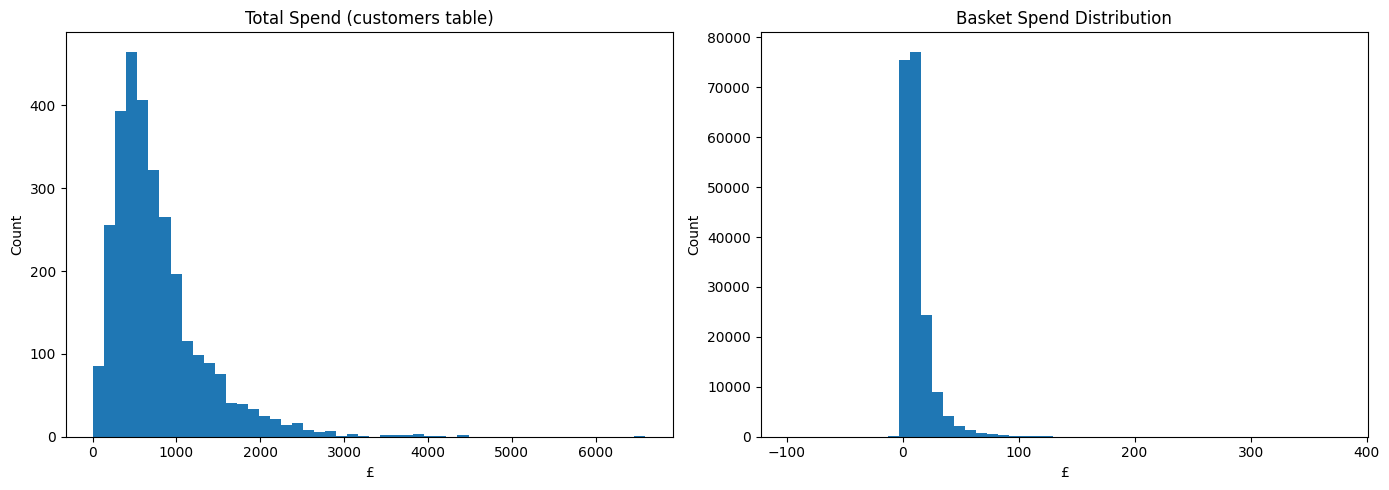

In [467]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of total_spend from customers table
axes[0].hist(customers["total_spend"], bins=50)
axes[0].set_title("Total Spend (customers table)")
axes[0].set_xlabel("£")
axes[0].set_ylabel("Count")

# Histogram of basket_spend from baskets table
axes[1].hist(baskets["basket_spend"], bins=50)
axes[1].set_title("Basket Spend Distribution")
axes[1].set_xlabel("£")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Feature engineering (customer-level)

In [468]:
ref_date = baskets["purchase_time"].max()       # # Reference date for recency = latest purchase in dataset

b = baskets.copy()
b["date"] = b["purchase_time"].dt.date
b["hour"] = b["purchase_time"].dt.hour
b["dow"] = b["purchase_time"].dt.dayofweek  # Monday=0, Sunday=6
b["is_weekend"] = (b["dow"] >= 5).astype(int)       # Weekend indicator (1 if Saturday or Sunday, 0 otherwise)

def daypart(hour):      # Define daypart based on hour of purchase
    if pd.isna(hour):
        return np.nan
    if hour < 12:
        return "morning"
    elif hour < 18:
        return "afternoon"
    else:
        return "evening"

b["daypart"] = b["hour"].apply(daypart)

basket_agg = b.groupby("customer_number").agg(      # Aggregate features from baskets table
    frequency_baskets=("purchase_time", "count"),
    monetary_basket_spend=("basket_spend", "sum"),
    avg_basket_spend=("basket_spend", "mean"),
    avg_basket_qty=("basket_quantity", "mean"),
    avg_basket_categories=("basket_categories", "mean"),
    last_purchase=("purchase_time", "max"),
    weekend_share=("is_weekend", "mean"),
)

basket_agg["recency_days"] = (ref_date - basket_agg["last_purchase"]).dt.days       # Calculate recency in days
basket_agg.drop(columns=["last_purchase"], inplace=True)

daypart_counts = (b.pivot_table(index="customer_number", columns="daypart", values="purchase_time", aggfunc="count", fill_value=0))     # Count purchases in each daypart per customer using pivot_table
daypart_shares = daypart_counts.div(daypart_counts.sum(axis=1), axis=0).add_prefix("share_")

features_baskets = basket_agg.join(daypart_shares, how="left").fillna(0)

features_baskets.head()

,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,avg_basket_categories,weekend_share,recency_days,share_afternoon,share_evening,share_morning
customer_number,,,,,,,,,,
14,56,675.72,12.066429,9.482143,4.464286,0.339286,1,0.857143,0.071429,0.071429
45,33,585.73,17.749394,19.848485,6.393939,0.000000,1,0.818182,0.030303,0.151515
52,59,222.18,3.765763,4.983051,2.949153,0.016949,2,0.644068,0.000000,0.355932
61,37,547.87,14.807297,13.486486,6.027027,0.135135,3,0.891892,0.027027,0.081081
63,48,293.34,6.111250,5.854167,3.666667,0.187500,7,0.770833,0.041667,0.187500


In [469]:
cat_cols = [c for c in category_spends.columns if c != "customer_number"]

cat = category_spends.copy()
cat["total_category_spend"] = cat[cat_cols].sum(axis=1)

cat["total_category_spend"] = cat["total_category_spend"].replace(0, np.nan)        # Avoid divide-by-zero by replacing 0 total spend with NaN

for c in cat_cols:
    cat[f"share_{c}"] = cat[c] / cat["total_category_spend"]

share_cols = [f"share_{c}" for c in cat_cols]
features_category = cat[["customer_number"] + share_cols].fillna(0)

features_category.head()

,customer_number,share_fruit_veg,share_dairy,share_confectionary,share_grocery_food,share_grocery_health_pets,share_bakery,share_newspapers_magazines,share_prepared_meals,share_soft_drinks,share_frozen,share_meat,share_tobacco,share_drinks,share_deli,share_world_foods,share_lottery,share_cashpoint,share_seasonal_gifting,share_discount_bakery,share_practical_items
0,11387,0.092553,0.051465,0.154466,0.038810,0.042407,0.038093,0.078580,0.009101,0.032719,0.030827,0.041017,0.232315,0.040157,0.040300,0.040902,0.002866,0.021497,0.010720,0.0,0.001204
1,8171,0.045734,0.100837,0.078092,0.090520,0.179795,0.054209,0.059733,0.032737,0.006336,0.213208,0.071593,0.000000,0.022799,0.007176,0.010181,0.000000,0.000000,0.027050,0.0,0.000000
2,1060,0.130556,0.124095,0.074595,0.030762,0.055393,0.113238,0.014731,0.086708,0.046539,0.021729,0.081728,0.000000,0.000000,0.003888,0.000000,0.026919,0.029910,0.159209,0.0,0.000000
3,3728,0.076125,0.168970,0.158953,0.108541,0.100607,0.101141,0.011820,0.023132,0.112689,0.013803,0.000860,0.115660,0.000000,0.000000,0.000000,0.003623,0.000000,0.000000,0.0,0.004076
4,14621,0.067042,0.231309,0.151073,0.055353,0.070874,0.063171,0.076385,0.000000,0.008924,0.006350,0.069101,0.000000,0.004862,0.189074,0.000000,0.000000,0.000000,0.006483,0.0,0.000000


In [470]:
base = customers.copy()
base = base.merge(features_baskets.reset_index(), on="customer_number", how="left")     # Merge basket features
base = base.merge(features_category, on="customer_number", how="left")      # Merge category features
base = base.fillna(0)       # Fill any missing (e.g., if a customer has no baskets—unlikely but safe)

base.shape

(3000, 36)

In [471]:
base.head()

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,avg_basket_categories,weekend_share,recency_days,share_afternoon,share_evening,share_morning,share_fruit_veg,share_dairy,share_confectionary,share_grocery_food,share_grocery_health_pets,share_bakery,share_newspapers_magazines,share_prepared_meals,share_soft_drinks,share_frozen,share_meat,share_tobacco,share_drinks,share_deli,share_world_foods,share_lottery,share_cashpoint,share_seasonal_gifting,share_discount_bakery,share_practical_items
0,4749,220,260,1.181818,631.12,2.87,92,631.12,6.860000,2.826087,1.923913,0.217391,3,0.326087,0.532609,0.141304,0.022896,0.056424,0.038043,0.015829,0.051797,0.022785,0.033147,0.048438,0.027538,0.016146,0.003438,0.002662,0.197870,0.000000,0.000000,0.000000,0.459501,0.000000,0.000000,0.003486
1,4757,248,333,1.342742,452.42,1.82,27,452.42,16.756296,12.333333,4.148148,0.222222,3,0.555556,0.259259,0.185185,0.181712,0.359798,0.101742,0.046771,0.046240,0.019009,0.003094,0.090403,0.041886,0.000000,0.013417,0.010300,0.048274,0.031365,0.000000,0.000000,0.000000,0.005990,0.000000,0.000000
2,144,226,303,1.340708,261.16,1.16,22,261.16,11.870909,13.772727,6.272727,0.000000,3,1.000000,0.000000,0.000000,0.135243,0.140412,0.187242,0.245597,0.030441,0.037180,0.017154,0.054794,0.001608,0.008003,0.032049,0.000000,0.009764,0.014550,0.081100,0.000000,0.000000,0.004863,0.000000,0.000000
3,572,285,346,1.214035,638.79,2.24,40,638.79,15.969750,8.650000,4.100000,0.125000,1,0.500000,0.000000,0.500000,0.062587,0.026347,0.068630,0.021102,0.005683,0.088715,0.066923,0.013760,0.015655,0.031074,0.032640,0.425555,0.000000,0.058032,0.017189,0.029744,0.000000,0.021776,0.009268,0.005323
4,669,285,324,1.136842,561.42,1.97,36,561.42,15.595000,9.000000,5.055556,0.361111,1,0.611111,0.194444,0.194444,0.026166,0.032792,0.011631,0.006181,0.041110,0.031848,0.033308,0.016316,0.066528,0.008870,0.084055,0.039756,0.569164,0.000000,0.001763,0.022265,0.000000,0.005290,0.000000,0.002957


## Feature selection sanity check

In [472]:
# # Drop potentially redundant columns
# drop_cols = [
#     "baskets",
#     "total_spend",
#     "average_spend",
#     "total_quantity",
#     "average_quantity"
# ]

# keep = base.drop(columns=[c for c in drop_cols if c in base.columns])

# # 1) Behaviour features
# behaviour_features = [
#     "frequency_baskets",
#     "monetary_basket_spend",
#     "avg_basket_spend",
#     "avg_basket_qty",
#     "avg_basket_categories",
#     "recency_days",
#     "weekend_share",
#     "share_morning", "share_afternoon", "share_evening"
# ]

# # 2) Category share features
# cat_share_features = [c for c in keep.columns if c.startswith("share_")
#                       and c not in ["share_morning", "share_afternoon", "share_evening"]]

# # 3) Combine
# wide_features = behaviour_features + cat_share_features
# X = keep[wide_features].copy()
# X = X.copy()

# # 4) Drop low-information category shares
# low_info_cols = [
#     "share_practical_items",
#     "share_discount_bakery",
#     "share_seasonal_gifting",
#     "share_world_foods"
# ]
# X = X.drop(columns=[c for c in low_info_cols if c in X.columns])

# print("Wide X shape:", X.shape)

In [473]:
import numpy as np

# Drop potentially redundant columns
drop_cols = [
    "baskets",
    "total_spend",
    "average_spend",
    "total_quantity",
    "average_quantity"
]

keep = base.drop(columns=[c for c in drop_cols if c in base.columns])

# 1) Behaviour features
behaviour_features = [
    "frequency_baskets",
    "monetary_basket_spend",
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "weekend_share",
    "share_morning", "share_afternoon", "share_evening"
]

# 2) Category share features
cat_share_features = [
    c for c in keep.columns
    if c.startswith("share_") and c not in ["share_morning", "share_afternoon", "share_evening"]
]

# 3) Combine
wide_features = behaviour_features + cat_share_features
X = keep[wide_features].copy()

# --- Replace correlated pair with ratio ---
X["spend_per_visit"] = X["monetary_basket_spend"] / X["frequency_baskets"].replace(0, np.nan)
X["spend_per_visit"] = X["spend_per_visit"].fillna(0)

# Drop the collinear originals
X = X.drop(columns=["monetary_basket_spend", "frequency_baskets"], errors="ignore")

# Keep your feature list consistent for later steps
behaviour_features = [c for c in behaviour_features if c not in ["monetary_basket_spend", "frequency_baskets"]]
behaviour_features.append("spend_per_visit")

# If you rely on wide_features later, rebuild it too
wide_features = behaviour_features + cat_share_features

# 4) Drop low-information category shares (keep this from your original Step 0)
low_info_cols = [
    "share_practical_items",
    "share_discount_bakery",
    "share_seasonal_gifting",
    "share_world_foods"
]
X = X.drop(columns=[c for c in low_info_cols if c in X.columns])

print("spend_per_visit in X?", "spend_per_visit" in X.columns)
print("monetary_basket_spend in X?", "monetary_basket_spend" in X.columns)
print("frequency_baskets in X?", "frequency_baskets" in X.columns)
print("Wide X shape:", X.shape)

spend_per_visit in X? True
monetary_basket_spend in X? False
frequency_baskets in X? False
Wide X shape: (3000, 25)


In [474]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# -----------------------
# Step 1: Preprocessing
# -----------------------
X_proc = X.copy()

# 1) Stricter winsorisation at p95 (caps extreme outliers)
winsor_cols = [
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "spend_per_visit",
]
for col in winsor_cols:
    if col in X_proc.columns:
        X_proc[col] = np.clip(X_proc[col], None, X_proc[col].quantile(0.95))

# 2) Log transform for skewed "magnitude" features (leave shares alone)
log_cols = [
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "spend_per_visit",
]
for col in log_cols:
    if col in X_proc.columns:
        X_proc[col] = np.log1p(np.clip(X_proc[col], 0, None))

# 3) Shares are already 0–1; keep as-is (optional safety clip)
share_cols = [c for c in X_proc.columns if c.startswith("share_")] + ["weekend_share"]
share_cols = [c for c in share_cols if c in X_proc.columns]
for col in share_cols:
    X_proc[col] = np.clip(X_proc[col], 0, 1)

# 4) Robust scaling (good when outliers still exist)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_proc)

print("X_proc shape:", X_proc.shape)
print("X_scaled shape:", X_scaled.shape)

X_proc shape: (3000, 25)
X_scaled shape: (3000, 25)


In [475]:
from sklearn.decomposition import PCA
import numpy as np

# -----------------------
# Step 2: PCA (try 8–12 comps)
# -----------------------

# 1) Inspect how much variance is captured as components increase
max_comps = min(20, X_scaled.shape[1])  # don't exceed feature count
pca_check = PCA(n_components=max_comps, random_state=42)
pca_check.fit(X_scaled)

cum_var = np.cumsum(pca_check.explained_variance_ratio_)
print("Cumulative explained variance:")
for i, v in enumerate(cum_var, start=1):
    print(f"{i:02d} comps: {v:.4f}")

# 2) Choose a larger PCA dimensionality (start with 10)
n_components = 6
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Chosen n_components:", n_components)
print("Variance captured:", pca.explained_variance_ratio_.sum())
print("X_pca shape:", X_pca.shape)

Cumulative explained variance:
01 comps: 0.5352
02 comps: 0.6475
03 comps: 0.6996
04 comps: 0.7443
05 comps: 0.7781
06 comps: 0.8107
07 comps: 0.8367
08 comps: 0.8598
09 comps: 0.8786
10 comps: 0.8944
11 comps: 0.9090
12 comps: 0.9225
13 comps: 0.9350
14 comps: 0.9471
15 comps: 0.9578
16 comps: 0.9684
17 comps: 0.9771
18 comps: 0.9848
19 comps: 0.9920
20 comps: 0.9978
Chosen n_components: 6
Variance captured: 0.810654473206729
X_pca shape: (3000, 6)


In [476]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

# -----------------------
# Step 3: Clustering (KMeans vs GMM)
# -----------------------
ks = [5, 6, 7]

rows = []
for k in ks:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=600)
    labels_km = km.fit_predict(X_pca)
    sil_km = silhouette_score(X_pca, labels_km)
    rows.append({"model": "KMeans", "k": k, "silhouette": sil_km})

    # # Gaussian Mixture
    # gm = GaussianMixture(n_components=k, random_state=42, n_init=20, covariance_type="full")
    # labels_gm = gm.fit_predict(X_pca)
    # sil_gm = silhouette_score(X_pca, labels_gm)
    # rows.append({"model": "GaussianMixture", "k": k, "silhouette": sil_gm})

results = pd.DataFrame(rows).sort_values(["silhouette"], ascending=False)
results

,model,k,silhouette
0,KMeans,5,0.311017
1,KMeans,6,0.310645
2,KMeans,7,0.305878


## Preprocessing: log transform + scaling

In [477]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

X_proc = X.copy()

# winsorise
for col in ["monetary_basket_spend","avg_basket_spend","avg_basket_qty","frequency_baskets"]:
    if col in X_proc.columns:
        X_proc[col] = np.clip(X_proc[col], None, X_proc[col].quantile(0.99))

# log transform behaviour features
for col in behaviour_features:
    if col in X_proc.columns and not col.startswith("share_") and col != "weekend_share":
        X_proc[col] = np.log1p(np.clip(X_proc[col], 0, None))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_proc)

# pca = PCA(n_components=5)
# X_pca = pca.fit_transform(X_scaled)
# print("PCA components:", X_pca.shape[1])

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# --- Grid search over n_components × k ---
max_comp = min(15, X_scaled.shape[1])
components_to_try = range(2, max_comp + 1)
k_values = range(5, 8)  # test 5, 6, 7; adjust as needed

rows = []
for n in components_to_try:
    X_pca_tmp = PCA(n_components=n, random_state=42).fit_transform(X_scaled)
    for k in k_values:
        labels = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=600).fit_predict(X_pca_tmp)
        score = silhouette_score(X_pca_tmp, labels)
        rows.append({"n_components": n, "k": k, "silhouette": score})

grid = pd.DataFrame(rows)

# --- "Within 1% of best, choose smallest n" rule ---
best_score = grid["silhouette"].max()
threshold = best_score * 0.99  # within 1%
near_best = grid[grid["silhouette"] >= threshold]
chosen = near_best.sort_values(["n_components", "k"]).iloc[0]

best_n = int(chosen["n_components"])
best_k = int(chosen["k"])

print(f"Global best silhouette: {best_score:.4f}")
print(f"Chosen n_components: {best_n}, k: {best_k}, silhouette: {chosen['silhouette']:.4f}")
print(f"\nAll configs within 1% of best:")
display(near_best.sort_values("silhouette", ascending=False))

# --- Final PCA + KMeans using auto-selected values ---
pca = PCA(n_components=best_n, random_state=42)
X_pca = pca.fit_transform(X_scaled)

km = KMeans(n_clusters=best_k, random_state=42, n_init=50, max_iter=600)
segment_idx = km.fit_predict(X_pca)

print(f"PCA components: {best_n}, variance captured: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Clusters: {best_k}, silhouette: {silhouette_score(X_pca, segment_idx):.4f}")

Global best silhouette: 0.6894
Chosen n_components: 2, k: 5, silhouette: 0.6894

All configs within 1% of best:


,n_components,k,silhouette
0,2,5,0.689374


PCA components: 2, variance captured: 0.6454
Clusters: 5, silhouette: 0.6894


In [478]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = [5, 6, 7]

inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_pca)
    
    inertia = km.inertia_
    silhouette = silhouette_score(X_pca, labels)
    
    inertias.append(inertia)
    silhouettes.append(silhouette)
    
    # print(k, silhouette)

results = pd.DataFrame({
    "k": ks,
    "inertia": inertias,
    "silhouette": silhouettes
})

results

,k,inertia,silhouette
0,5,15854.869587,0.689374
1,6,12731.365237,0.669867
2,7,10625.686259,0.606398


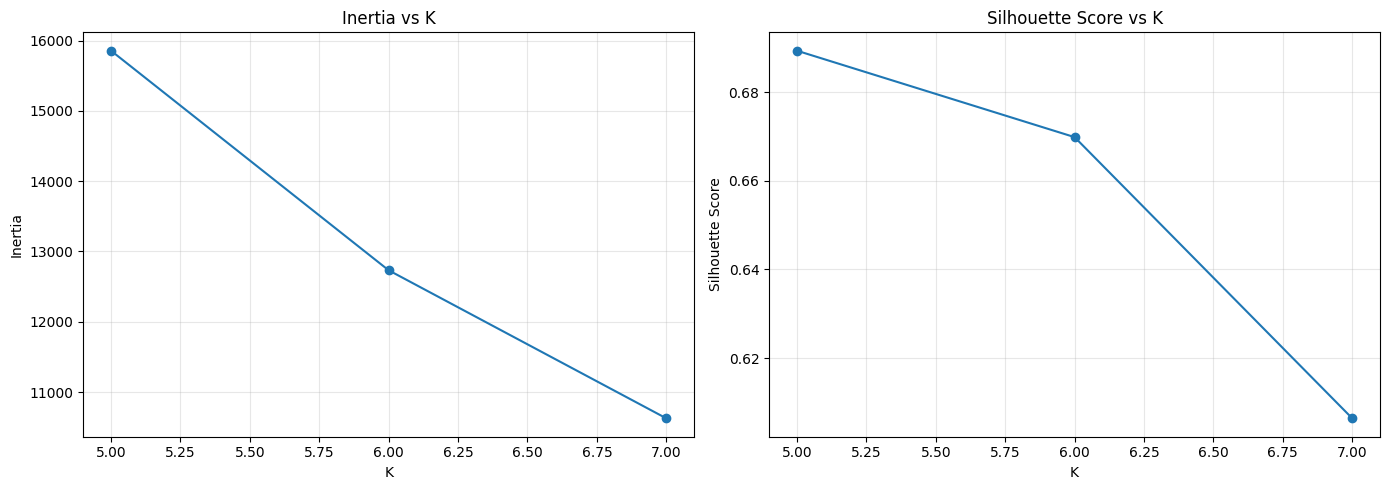

In [479]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Inertia (Elbow)
axes[0].plot(results["k"], results["inertia"], marker="o")
axes[0].set_title("Inertia vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(results["k"], results["silhouette"], marker="o")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [480]:
# best_k = results.loc[results["silhouette"].idxmax(), "k"]
# best_k = int(best_k) # type: ignore[arg-type]
# final_km = KMeans(n_clusters=best_k, random_state=42, n_init=50)
# segment_idx = final_km.fit_predict(X_pca)

best_k = 5
km = KMeans(n_clusters=best_k, random_state=42, n_init=50, max_iter=600)
segment_idx = km.fit_predict(X_pca)

seg = keep[["customer_number"]].copy()

seg["segment_id"] = segment_idx + 1
seg["segment_name"] = seg["segment_id"].apply(lambda x: f"Customer clutter {x}")

seg.head()

,customer_number,segment_id,segment_name
0,4749,3,Customer clutter 3
1,4757,1,Customer clutter 1
2,144,1,Customer clutter 1
3,572,1,Customer clutter 1
4,669,1,Customer clutter 1


In [481]:
segment_sizes = (               # Calculate segment sizes by counting customers in each segment_name
    seg["segment_name"]
    .value_counts()
    .rename_axis("segment_name")
    .reset_index(name="n_customers")
)

segment_sizes["pct_customers"] = segment_sizes["n_customers"] / segment_sizes["n_customers"].sum()      # Add percentage of customers in each segment
segment_sizes

,segment_name,n_customers,pct_customers
0,Customer clutter 1,2351,0.783667
1,Customer clutter 5,261,0.087000
2,Customer clutter 3,258,0.086000
3,Customer clutter 2,105,0.035000
4,Customer clutter 4,25,0.008333


In [482]:
profile_df = keep.merge(seg, on="customer_number", how="left")

key_features = [        # smaller set of key features for the main table
    "frequency_baskets",
    "monetary_basket_spend",
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "weekend_share",
]

for c in ["share_morning", "share_afternoon", "share_evening"]:
    if c in profile_df.columns:
        key_features.append(c)

summary_means = profile_df.groupby("segment_name")[key_features].mean().round(3)
summary_medians = profile_df.groupby("segment_name")[key_features].median().round(3)

summary_means

,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,avg_basket_categories,recency_days,weekend_share,share_morning,share_afternoon,share_evening
segment_name,,,,,,,,,,
Customer clutter 1,60.591,754.779,15.732,12.417,4.909,8.827,0.230,0.337,0.548,0.115
Customer clutter 2,93.533,805.396,10.407,6.495,3.699,6.152,0.242,0.376,0.509,0.114
Customer clutter 3,73.818,815.189,12.613,6.782,3.754,6.403,0.225,0.339,0.521,0.140
Customer clutter 4,88.800,840.945,10.664,6.271,3.681,2.240,0.212,0.491,0.408,0.101
Customer clutter 5,84.333,834.656,10.747,7.813,4.154,4.808,0.249,0.381,0.521,0.098


In [483]:
cat_share_cols = []
for col in profile_df.columns:
    if col.startswith("share_") and col not in ["share_morning","share_afternoon","share_evening"]:     # Identify category share columns (those starting with "share_" but not the daypart shares)
        cat_share_cols.append(col)

seg_cat_means = profile_df.groupby("segment_name")[cat_share_cols].mean()

top5_by_segment = {}
for seg_name in seg_cat_means.index:        # For each segment, find the top 5 category shares
    row = seg_cat_means.loc[seg_name]
    top5 = row.sort_values(ascending=False).head(5)
    top5_by_segment[seg_name] = top5

for seg_name in top5_by_segment:
    print("\nSegment:", seg_name)
    print("------------------------")
    for category, value in top5_by_segment[seg_name].items():
        clean_name = category.replace("share_", "")
        print(clean_name, ":", round(value, 3))


Segment: Customer clutter 1
------------------------
dairy : 0.107
fruit_veg : 0.105
grocery_food : 0.089
grocery_health_pets : 0.087
confectionary : 0.085

Segment: Customer clutter 2
------------------------
lottery : 0.165
tobacco : 0.145
cashpoint : 0.117
dairy : 0.07
fruit_veg : 0.062

Segment: Customer clutter 3
------------------------
cashpoint : 0.346
tobacco : 0.123
dairy : 0.065
confectionary : 0.06
grocery_health_pets : 0.051

Segment: Customer clutter 4
------------------------
lottery : 0.361
tobacco : 0.104
fruit_veg : 0.062
dairy : 0.061
drinks : 0.061

Segment: Customer clutter 5
------------------------
tobacco : 0.157
dairy : 0.086
fruit_veg : 0.071
drinks : 0.071
grocery_food : 0.067


## Pen profiles (customer archetypes)

A good pen profile usually mentions:
- **Value** (high/low spend; basket spend)
- **Frequency** (regular vs occasional)
- **Mission** (quick top-up vs broad shop: avg_basket_categories, avg_basket_qty)
- **Timing** (weekend/morning/evening)
- **Preferences** (top categories by share)

In [484]:
def fmt_pct(x):
    return f"{100*x:.1f}%"

pen_profile_rows = []
for seg_name in sorted(profile_df["segment_name"].unique()):
    sub = profile_df[profile_df["segment_name"] == seg_name]

    # calculate key stats
    avg_spend = sub["avg_basket_spend"].mean()
    freq = sub["frequency_baskets"].mean()
    rec = sub["recency_days"].mean()
    weekend = sub["weekend_share"].mean()
    cats = sub["avg_basket_categories"].mean()

    
    top_cats = seg_cat_means.loc[seg_name].sort_values(ascending=False).head(3)     # Get top 3 category shares for this segment
    top_cats_str = ", ".join([f"{c.replace('share_','')} ({fmt_pct(v)})" for c,v in top_cats.items()])

    # store results
    pen_profile_rows.append({
        "segment_name": seg_name,
        "frequency_baskets": round(freq, 1),
        "avg_basket_spend": round(avg_spend, 2),
        "recency_days": round(rec, 1),
        "weekend_share": fmt_pct(weekend),
        "basket_category_breadth": round(cats, 2),
        "top_categories": top_cats_str,
        "pen_profile_prompt": (
            f"{seg_name}: visits ~{freq:.1f} times, spends ~£{avg_spend:.2f} per basket, "
            f"last visited ~{rec:.1f} days ago, shops on weekends ~{fmt_pct(weekend)}, "
            f"buys across ~{cats:.2f} categories. Top categories: {top_cats_str}."
        )
    })


pen_profiles = pd.DataFrame(pen_profile_rows)
pd.set_option('display.max_colwidth', None)
pen_profiles[["segment_name", "pen_profile_prompt"]]    # show only segment name and profile text

,segment_name,pen_profile_prompt
0,Customer clutter 1,"Customer clutter 1: visits ~60.6 times, spends ~£15.73 per basket, last visited ~8.8 days ago, shops on weekends ~23.0%, buys across ~4.91 categories. Top categories: dairy (10.7%), fruit_veg (10.5%), grocery_food (8.9%)."
1,Customer clutter 2,"Customer clutter 2: visits ~93.5 times, spends ~£10.41 per basket, last visited ~6.2 days ago, shops on weekends ~24.2%, buys across ~3.70 categories. Top categories: lottery (16.5%), tobacco (14.5%), cashpoint (11.7%)."
2,Customer clutter 3,"Customer clutter 3: visits ~73.8 times, spends ~£12.61 per basket, last visited ~6.4 days ago, shops on weekends ~22.5%, buys across ~3.75 categories. Top categories: cashpoint (34.6%), tobacco (12.3%), dairy (6.5%)."
3,Customer clutter 4,"Customer clutter 4: visits ~88.8 times, spends ~£10.66 per basket, last visited ~2.2 days ago, shops on weekends ~21.2%, buys across ~3.68 categories. Top categories: lottery (36.1%), tobacco (10.4%), fruit_veg (6.2%)."
4,Customer clutter 5,"Customer clutter 5: visits ~84.3 times, spends ~£10.75 per basket, last visited ~4.8 days ago, shops on weekends ~24.9%, buys across ~4.15 categories. Top categories: tobacco (15.7%), dairy (8.6%), fruit_veg (7.1%)."


In [485]:
seg_kpis = profile_df.groupby("segment_name").agg(      # Aggregate key KPIs by segment for attractiveness scoring
    n_customers=("customer_number", "count"),
    mean_frequency=("frequency_baskets", "mean"),
    mean_monetary=("monetary_basket_spend", "mean"),
    mean_recency=("recency_days", "mean"),
    mean_avg_basket_spend=("avg_basket_spend", "mean")
).reset_index()

def minmax(s):
    if s.max() == s.min():      # handle constant series to avoid divide-by-zero
        return np.zeros_like(s, dtype=float)
    return (s - s.min()) / (s.max() - s.min())

tmp = seg_kpis.copy()
tmp["freq_norm"] = minmax(tmp["mean_frequency"])    # Normalize frequency higher = better
tmp["mon_norm"] = minmax(tmp["mean_monetary"])      # Normalize monetary higher = better
tmp["rec_norm"] = 1 - minmax(tmp["mean_recency"])   # lower recency = better

w_freq, w_mon, w_rec = 0.35, 0.45, 0.20  # weights can be justified in the report

tmp["attractiveness_score"] = (
    w_freq * tmp["freq_norm"] +
    w_mon * tmp["mon_norm"] +
    w_rec * tmp["rec_norm"]
)

seg_ranking = tmp.sort_values("attractiveness_score", ascending=False)      # Sort segments by attractiveness
seg_ranking

,segment_name,n_customers,mean_frequency,mean_monetary,mean_recency,mean_avg_basket_spend,freq_norm,mon_norm,rec_norm,attractiveness_score
3,Customer clutter 4,25,88.800000,840.944800,2.240000,10.664042,0.856314,1.000000,1.000000,0.949710
4,Customer clutter 5,261,84.333333,834.656398,4.808429,10.747461,0.720722,0.927020,0.610069,0.791426
1,Customer clutter 2,105,93.533333,805.396381,6.152381,10.407271,1.000000,0.587444,0.406034,0.695557
2,Customer clutter 3,258,73.817829,815.189380,6.403101,12.612946,0.401510,0.701096,0.367971,0.529616
0,Customer clutter 1,2351,60.591238,754.778558,8.826882,15.731529,0.000000,0.000000,0.000000,0.000000


In [486]:
output_path = "customer_segments01.csv"

seg.sort_values("customer_number").to_csv(output_path, index=False)

output_path

'customer_segments01.csv'

In [487]:
pd.read_csv(output_path).head()

,customer_number,segment_id,segment_name
0,14,1,Customer clutter 1
1,45,1,Customer clutter 1
2,52,1,Customer clutter 1
3,61,1,Customer clutter 1
4,63,1,Customer clutter 1


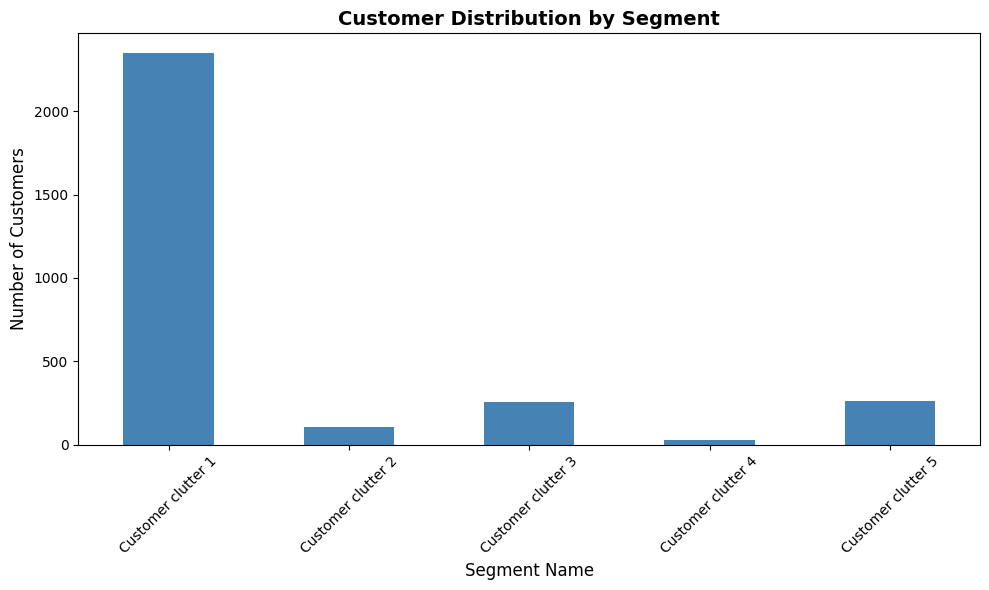

In [488]:
output_df = pd.read_csv(output_path)

# Segment counts
segment_counts = (
    output_df["segment_name"]
    .value_counts()
    .sort_index()
    .reset_index()
)
segment_counts.columns = ["segment_name", "count"]

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

segment_counts = output_df['segment_name'].value_counts().sort_index()
segment_counts.plot(kind='bar', ax=ax, color='steelblue')

ax.set_title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment Name', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

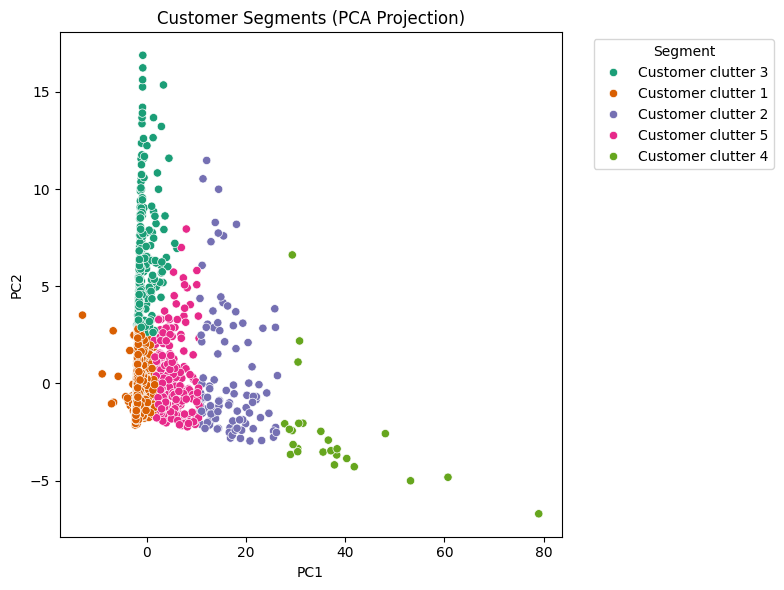

In [489]:
from sklearn.decomposition import PCA
import seaborn as sns

X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=seg["segment_name"].values, palette="Dark2")
plt.title("Customer Segments (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [492]:
for n_comp in range (5,9):
    pca = PCA(n_components=n_comp, random_state=42)
    X_p = pca.fit_transform(X_scaled)
    print("n_comp=", n_comp, "explained=", pca.explained_variance_ratio_.sum())
    for k in range (5,8):
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X_pca)
        print(" k=",k,"silhouette=", round(silhouette_score(X_pca, labels),3))
    print()

n_comp= 5 explained= 0.777395057899673
 k= 5 silhouette= 0.689
 k= 6 silhouette= 0.669
 k= 7 silhouette= 0.605

n_comp= 6 explained= 0.8097682853005221
 k= 5 silhouette= 0.689
 k= 6 silhouette= 0.669
 k= 7 silhouette= 0.605

n_comp= 7 explained= 0.8368448331331236
 k= 5 silhouette= 0.689
 k= 6 silhouette= 0.669
 k= 7 silhouette= 0.605

n_comp= 8 explained= 0.859783803673747
 k= 5 silhouette= 0.689
 k= 6 silhouette= 0.669
 k= 7 silhouette= 0.605



In [493]:
for n_comp in range (5,9):
    pca = PCA(n_components=n_comp, random_state=42)
    X_p = pca.fit_transform(X_scaled)
    print("n_comp=", n_comp, "explained=", pca.explained_variance_ratio_.sum())
    for k in range (5,8):
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X_p)
        print(" k=",k,"silhouette=", round(silhouette_score(X_pca, labels),3))
    print()

n_comp= 5 explained= 0.777395057899673
 k= 5 silhouette= 0.41
 k= 6 silhouette= 0.353
 k= 7 silhouette= 0.119

n_comp= 6 explained= 0.8097682853005221
 k= 5 silhouette= 0.409
 k= 6 silhouette= 0.345
 k= 7 silhouette= 0.083

n_comp= 7 explained= 0.8368448331331236
 k= 5 silhouette= 0.398
 k= 6 silhouette= 0.344
 k= 7 silhouette= 0.109

n_comp= 8 explained= 0.859783803673747
 k= 5 silhouette= 0.399
 k= 6 silhouette= 0.344
 k= 7 silhouette= 0.109

